In [1]:
import tensorflow as tf
print(tf.__version__)


2.15.0


In [2]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
DATA_DIR ="/Users/praneeth/Documents/newplantvillage_data"


In [4]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)


Found 50396 images belonging to 34 classes.
Found 12583 images belonging to 34 classes.


In [5]:
class_names = list(train_gen.class_indices.keys())
print(class_names)


['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [6]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input

base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs, outputs)


In [7]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [8]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)


Epoch 1/10
1575/1575 [==============================] - 162s 103ms/step - loss: 0.6844 - accuracy: 0.7924 - val_loss: 0.2887 - val_accuracy: 0.9087
Epoch 2/10
1575/1575 [==============================] - 164s 104ms/step - loss: 0.3337 - accuracy: 0.8910 - val_loss: 0.2549 - val_accuracy: 0.9178
Epoch 3/10
1575/1575 [==============================] - 158s 100ms/step - loss: 0.2704 - accuracy: 0.9109 - val_loss: 0.2451 - val_accuracy: 0.9216
Epoch 4/10
1575/1575 [==============================] - 168s 107ms/step - loss: 0.2306 - accuracy: 0.9211 - val_loss: 0.2376 - val_accuracy: 0.9249
Epoch 5/10
1575/1575 [==============================] - 172s 109ms/step - loss: 0.2031 - accuracy: 0.9305 - val_loss: 0.2316 - val_accuracy: 0.9261
Epoch 6/10
1575/1575 [==============================] - 170s 108ms/step - loss: 0.1883 - accuracy: 0.9364 - val_loss: 0.2239 - val_accuracy: 0.9306
Epoch 7/10
1575/1575 [==============================] - 159s 101ms/step - loss: 0.1757 - accuracy: 0.9389 - val_

In [9]:
model.save('plant_disease_model_version2.h5')
print("Model saved as plant_disease_model_version2.h5")


Model saved as plant_disease_model_version2.h5


/Users/praneeth/Documents/GitHub/crop2.0/server/venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [10]:
model.save("plant_disease_model_version2.keras")
print("Model saved as plant_disease_model_version2.keras")


Model saved as plant_disease_model_version2.keras


  Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.8-cp310-cp310-macosx_11_0_arm64.whl.metadata (6.2 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 9.5 MB/s eta 0:00:00a 0:00:01m
Using cached contourpy-1.3.2-cp310-cp310-macosx_11_0_arm64.whl (253 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 11.4 MB/s eta 0:00:00a 0:00:01
Using cached kiwisolver-1.4.8-cp310-cp310-macosx_11_0_arm64.whl (65 kB)
Using cached pyparsing-3.2.3-py3-none-any.whl (111 kB)

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


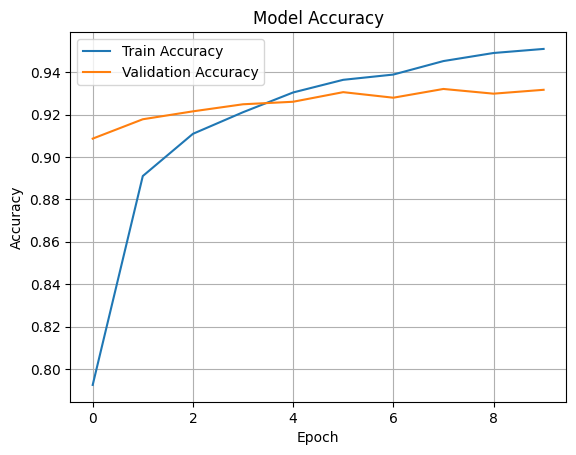

In [12]:
%pip install matplotlib
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


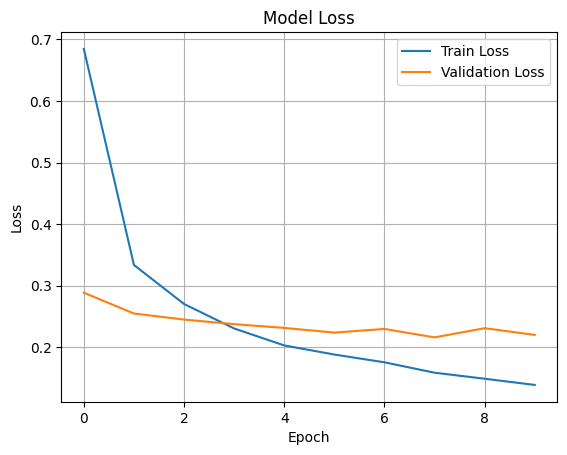

In [13]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [15]:
%pip install scikit-learn
from sklearn.metrics import classification_report
import numpy as np


  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 13.3 MB/s eta 0:00:00 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
# Reset the generator before predicting
val_gen.reset()

# Get predictions
pred_probs = model.predict(val_gen, verbose=1)

# Convert predicted probabilities to class indices
y_pred = np.argmax(pred_probs, axis=1)


394/394 [==============================] - 31s 77ms/step


In [17]:
y_true = val_gen.classes


In [18]:
class_labels = list(val_gen.class_indices.keys())


In [19]:
report = classification_report(y_true, y_pred, target_names=class_labels)
print(report)


                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.04      0.04      0.04       403
                            Apple___Black_rot       0.04      0.04      0.04       397
                     Apple___Cedar_apple_rust       0.03      0.03      0.03       352
                              Apple___healthy       0.03      0.02      0.03       401
                          Blueberry___healthy       0.03      0.03      0.03       363
     Cherry_(including_sour)___Powdery_mildew       0.02      0.02      0.02       336
            Cherry_(including_sour)___healthy       0.04      0.04      0.04       365
                            Grape___Black_rot       0.03      0.03      0.03       377
                 Grape___Esca_(Black_Measles)       0.02      0.02      0.02       384
   Grape___Leaf_blight_(Isariopsis_Leaf_Spot)       0.04      0.04      0.04       344
                              Grape___heal

In [22]:
# Confirm class indices match
print(val_gen.class_indices)
print(class_labels)


{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Grape___Black_rot': 7, 'Grape___Esca_(Black_Measles)': 8, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 9, 'Grape___healthy': 10, 'Orange___Haunglongbing_(Citrus_greening)': 11, 'Peach___Bacterial_spot': 12, 'Peach___healthy': 13, 'Pepper,_bell___Bacterial_spot': 14, 'Pepper,_bell___healthy': 15, 'Potato___Early_blight': 16, 'Potato___Late_blight': 17, 'Potato___healthy': 18, 'Raspberry___healthy': 19, 'Soybean___healthy': 20, 'Squash___Powdery_mildew': 21, 'Strawberry___Leaf_scorch': 22, 'Strawberry___healthy': 23, 'Tomato___Bacterial_spot': 24, 'Tomato___Early_blight': 25, 'Tomato___Late_blight': 26, 'Tomato___Leaf_Mold': 27, 'Tomato___Septoria_leaf_spot': 28, 'Tomato___Spider_mites Two-spotted_spider_mite': 29, 'Tomato___Target_Spot': 30, 'Tomato___Tomato_Yellow_Leaf_Cu

In [23]:
import numpy as np
from tensorflow.keras.preprocessing import image


In [46]:
img_path = '/Users/praneeth/Downloads/download (2).jpeg'
img = image.load_img(img_path, target_size=IMG_SIZE)  # Same as used in training, e.g., (128, 128)

img_array = image.img_to_array(img)
img_array = img_array / 255.0  # match rescale from ImageDataGenerator
img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension


In [47]:
pred = model.predict(img_array)
predicted_class = class_labels[np.argmax(pred)]
confidence = np.max(pred)


1/1 [==============================] - 0s 32ms/step


In [48]:
print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}")


Predicted Class: Peach___Bacterial_spot
Confidence: 0.98
